In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import umap
from matplotlib import colors
from PIL import Image
import os
import pandas as pd
from scipy.spatial import cKDTree

# Use inline matplotlib (interactive widget requires: pip install ipympl)
%matplotlib inline

In [3]:
root_dir = Path('C:/Users/koket/Desktop/BLUSE')
data_dir = root_dir / "data"
features_dir = root_dir / "features"
output_dir = root_dir / "outputs"
h5_file = data_dir / 'mk_sample_hits.h5'

In [4]:
f = h5py.File(h5_file,'r')
data = f['data'][:]
data = data.squeeze()

In [5]:
filename = f'mk_sample_resnet18_patch_features.parquet'
features_df = pd.read_parquet(features_dir / filename)
anomaly_scores_df = pd.read_parquet(output_dir / "mk_sample_resnet18_patch_features_knn_algorithm.parquet")

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [6]:
um = umap.UMAP(metric='euclidean', n_neighbors=15, min_dist=0.05)
um_feats = pd.DataFrame(index=features_df.index, data=um.fit_transform(features_df))

NameError: name 'features_df' is not defined

In [ ]:
def umap_browser(embedding, data, scores=None, cmap_spec="viridis",
                 image_shape=None):
    # order the points: by score if we have one, otherwise as given
    if scores is not None:
        s = scores["score"].reindex(embedding.index)
        if s.isna().any():
            raise ValueError("some embedding ids are missing from scores")
        order = s.sort_values().index          # lowest -> highest
        colour = s.loc[order].to_numpy()
    else:
        order = embedding.index
        colour = None

    emb = embedding.loc[order].iloc[:, :2].to_numpy()
    ids = np.asarray(order)                    # positional index -> id
    tree = cKDTree(emb)

    def get_image(row_id):
        """Pull one image out of `data`, whatever shape it's stored in."""
        if isinstance(data, pd.DataFrame):
            row = data.loc[row_id]
            if len(row) == 1 and isinstance(row.iloc[0], np.ndarray):
                img = row.iloc[0]              # one cell holding the array
            else:
                img = row.to_numpy()           # flattened pixels across columns
        else:
            img = np.asarray(data)[embedding.index.get_loc(row_id)]
        img = np.asarray(img)
        if img.ndim == 1:
            if image_shape is None:
                raise ValueError("image is flat; pass image_shape=(57, 120)")
            img = img.reshape(image_shape)
        return np.squeeze(img)

    fig = plt.figure(figsize=(10, 5))
    ax_umap = fig.add_subplot(1, 2, 1)
    ax_spec = fig.add_subplot(1, 2, 2)

    sc = ax_umap.scatter(
        emb[:, 0], emb[:, 1],
        c=colour if colour is not None else "steelblue",
        s=3, cmap="magma", picker=True,
    )
    if colour is not None:
        fig.colorbar(sc, ax=ax_umap, fraction=0.046, label="anomaly score")
    ax_umap.set_title("click a point")
    ax_umap.set_xticks([])
    ax_umap.set_yticks([])

    marker, = ax_umap.plot([], [], "o", ms=12, mfc="none", mec="red", mew=2)

    def show(pos):
        row_id = ids[pos]
        ax_spec.clear()

        # robust limits so one hot pixel doesn't flatten the display
        d = get_image(row_id)
        lo, hi = np.percentile(d, [1, 99.5])
        h, w = d.shape
        ax_spec.imshow(d, aspect="auto", origin="lower",
                       cmap=cmap_spec, vmin=lo, vmax=hi,
                       extent=[0, w, 0, h])
        title = f"id {row_id}"
        if colour is not None:
            title += f"   score {colour[pos]:.3f}"
        ax_spec.set_title(title)
        ax_spec.set_xlabel("frequency channel")
        ax_spec.set_ylabel("time sample")

        marker.set_data([emb[pos, 0]], [emb[pos, 1]])
        fig.canvas.draw_idle()

    def on_click(event):
        if event.inaxes is not ax_umap or event.xdata is None:
            return
        _, pos = tree.query([event.xdata, event.ydata])
        show(int(pos))

    fig.canvas.mpl_connect("button_press_event", on_click)

    show(0)
    plt.tight_layout()
    return fig

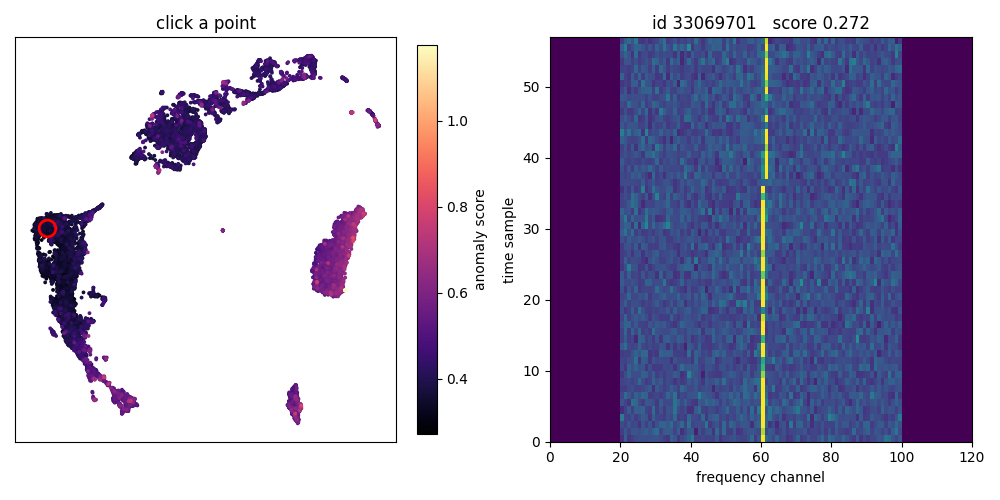

In [ ]:
fig = umap_browser(um_feats, data, anomaly_scores_df)
plt.show()